# Apple Phenology — Process-Based Models

Loads the PEP725 apple (*Malus domestica*) dataset, explores it visually,
fits all available process-based models on the two dominant phenological
groups — **early cultivar** (subgroup 100) and **late cultivar** (subgroup 130)
— using a temporal train/test split (train: 1986–2009, test: 2010–2015),
evaluates and compares the results, and finally visualises how each model's
chill and forcing responses differ on a single representative sample per group.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pysephone.constants import KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.gdd import GDDModel
from pysephone.models.cf import (
    UtahGDDModel,
    ChillingDaysGDDModel,
    DynamicGDDModel,
)
from pysephone.models.util.func_phenology import (
    func_utah_chill,
    func_chilling_days,
    func_dynamic_chill_daily,
)
from pysephone.visualize.dataset import (
    observation_doy_histograms,
    observation_doy_over_time,
    observation_map,
    observation_mean_trend,
)

## 1. Load data

The target phenophase is `BBCH_60` (first flowering).  
A season starting 1 October and running for 365 days captures the full
winter chilling period and the spring forcing phase.

The full dataset is loaded once; the two dominant cultivar groups are
obtained by subgroup selection, avoiding any extra downloads.

In [ ]:
from pysephone.dataset.util.feature_cache import FeatureCache

DATA_KEYS = ['temperature_2m_mean']

OBS_KEY      = 'BBCH_60'
CUTOFF       = 2010
OPT_MAX_TIME = 60.0

SUBGROUP_EARLY = ('pep725', 220, 100)
SUBGROUP_LATE  = ('pep725', 220, 130)

cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('PEP725_Apple', DATA_KEYS))
ds_all = Dataset.load('PEP725_Apple', calendar=cal, feature_providers=[_cache])

ds_early = ds_all.select_species([SUBGROUP_EARLY])
ds_late  = ds_all.select_species([SUBGROUP_LATE])

for name, ds in [('All', ds_all), ('Early cultivar', ds_early), ('Late cultivar', ds_late)]:
    print(f"{name:15s}: {len(ds):5d} samples | "
          f"years {min(ds.years)}–{max(ds.years)} | "
          f"locations {len(ds.locations)}")


## 2. Explore the datasets

### 2a. Full dataset

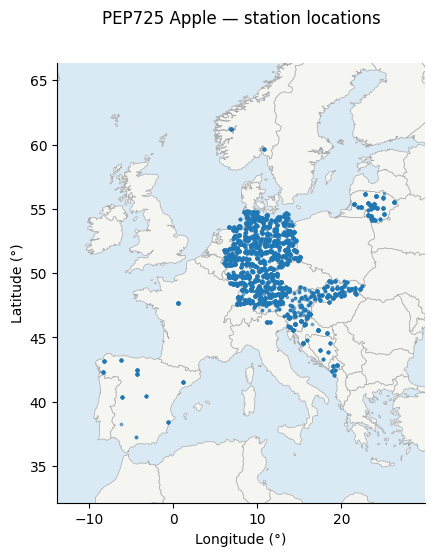

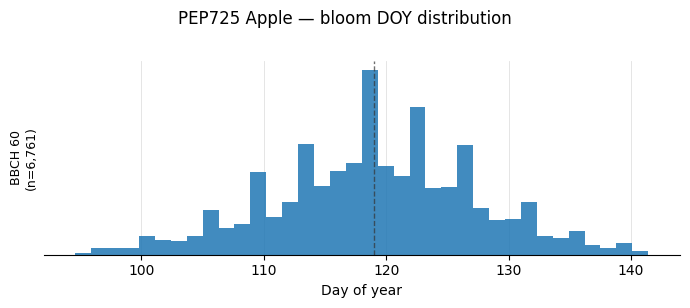

In [3]:
obs_all = ds_all.observations

fig = observation_map(obs_all)
fig.suptitle('PEP725 Apple — station locations', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs_all)
fig.suptitle('PEP725 Apple — bloom DOY distribution', y=1.01)
plt.tight_layout()
plt.show()

### 2b. Early cultivar (subgroup 100)

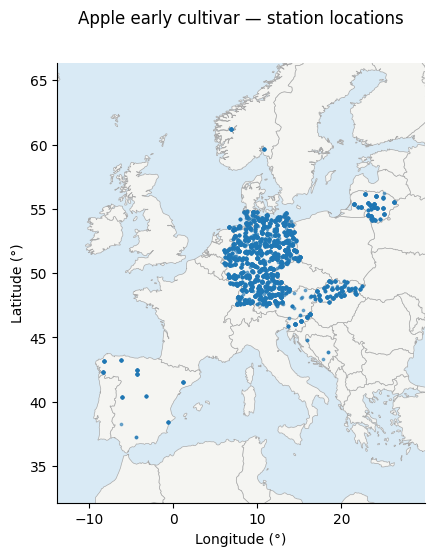

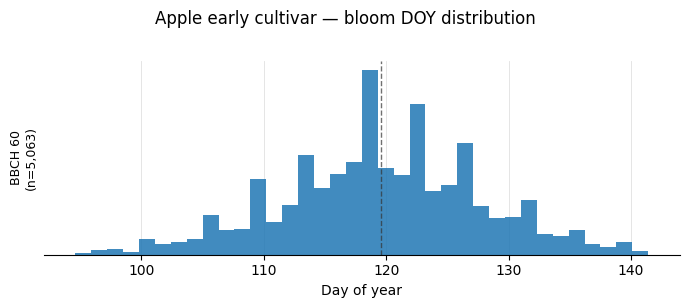

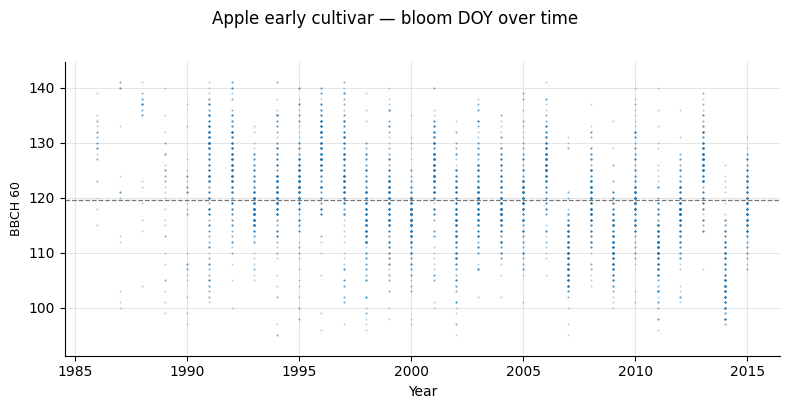

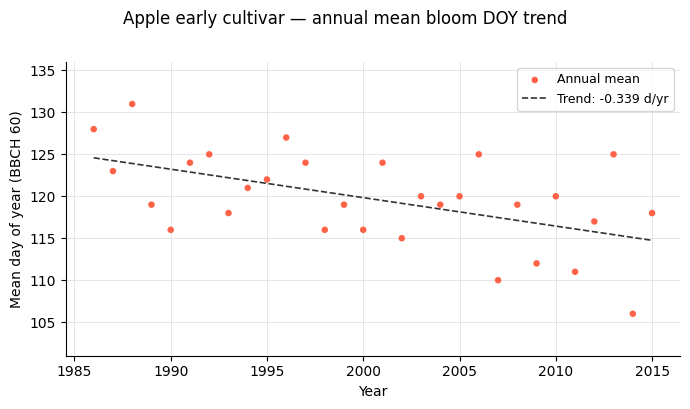

In [4]:
obs_early = ds_early.observations

fig = observation_map(obs_early)
fig.suptitle('Apple early cultivar — station locations', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs_early)
fig.suptitle('Apple early cultivar — bloom DOY distribution', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_over_time(obs_early)
fig.suptitle('Apple early cultivar — bloom DOY over time', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_mean_trend(obs_early, OBS_KEY)
fig.suptitle('Apple early cultivar — annual mean bloom DOY trend', y=1.01)
plt.tight_layout()
plt.show()

### 2c. Late cultivar (subgroup 130)

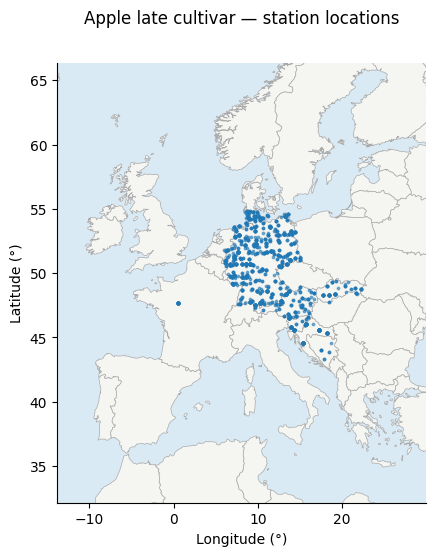

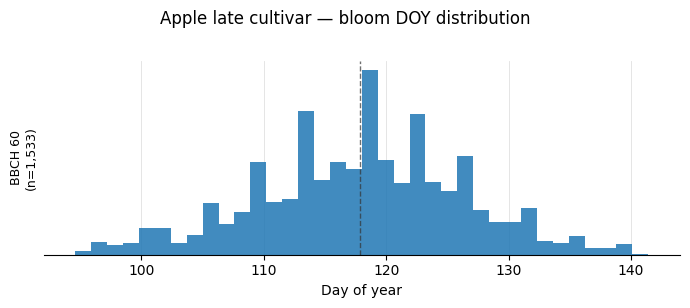

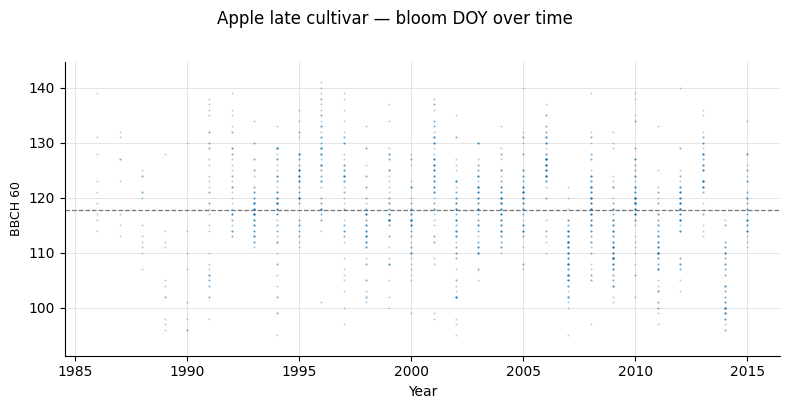

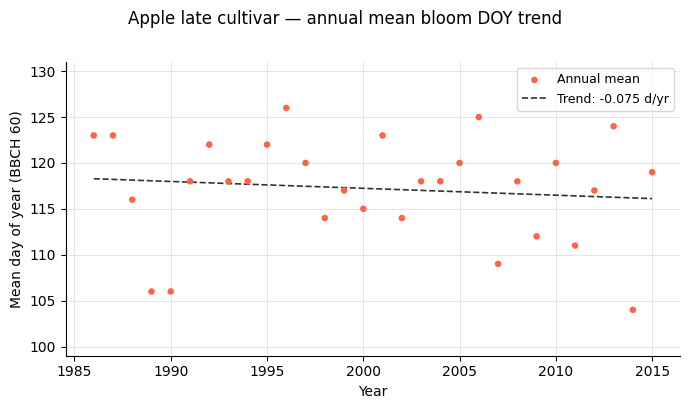

In [5]:
obs_late = ds_late.observations

fig = observation_map(obs_late)
fig.suptitle('Apple late cultivar — station locations', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_histograms(obs_late)
fig.suptitle('Apple late cultivar — bloom DOY distribution', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_doy_over_time(obs_late)
fig.suptitle('Apple late cultivar — bloom DOY over time', y=1.01)
plt.tight_layout()
plt.show()

fig = observation_mean_trend(obs_late, OBS_KEY)
fig.suptitle('Apple late cultivar — annual mean bloom DOY trend', y=1.01)
plt.tight_layout()
plt.show()

## 3. Train / test split

Temporal cutoff: **train 1986–2009**, **test 2010–2015**.

In [6]:
def temporal_split(ds, cutoff):
    years = sorted(ds.years)
    trn = [y for y in years if y < cutoff]
    tst = [y for y in years if y >= cutoff]
    return ds.select_years(trn), ds.select_years(tst)

ds_early_trn, ds_early_tst = temporal_split(ds_early, CUTOFF)
ds_late_trn,  ds_late_tst  = temporal_split(ds_late,  CUTOFF)

for group, trn, tst in [
    ('Early', ds_early_trn, ds_early_tst),
    ('Late',  ds_late_trn,  ds_late_tst),
]:
    print(f"{group}: train {len(trn)}, test {len(tst)}")

Early: train 3956, test 1107
Late: train 1193, test 340


## 4. Fit process-based models

Four models are fitted on each cultivar group independently:

| Model | Chilling | Forcing |
|---|---|---|
| `GDDModel` | — | GDU from season start |
| `UtahGDDModel` | Utah chill units | GDU after chill gate |
| `ChillingDaysGDDModel` | Days ≤ *t_chill* | GDU after chill gate |
| `DynamicGDDModel` | Dynamic (chill portions) | GDU after chill gate |

In [7]:
target_fn = lambda s: s['observations'][OBS_KEY]

OPT_KW = dict(opt_max_time=OPT_MAX_TIME)

MODEL_SPECS = [
    (
        'GDD',
        GDDModel,
        dict(threshold=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'Utah+GDD',
        UtahGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
    (
        'ChillingDays+GDD',
        ChillingDaysGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, **OPT_KW),
    ),
    (
        'Dynamic+GDD',
        DynamicGDDModel,
        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW),
    ),
]

fitted = {}  # {group: {model_name: model}}

for group, ds_trn in [('early', ds_early_trn), ('late', ds_late_trn)]:
    fitted[group] = {}
    for name, cls, kwargs in MODEL_SPECS:
        print(f"Fitting {name} on {group}...", end=' ', flush=True)
        model, _ = cls.fit(
            target_fn=target_fn,
            dataset=ds_trn,
            model_kwargs=kwargs,
        )
        fitted[group][name] = model
        print('done')
        print(f"  params: {model.params}")

Fitting GDD on early... done
  params: {'threshold': 977.9263268285936, 't_base': 0.6850654883921532}
Fitting Utah+GDD on early... done
  params: {'th_c': 34.86494943844844, 'th_f': 328.9941851038902, 't_base': 3.1236242629635216}
Fitting ChillingDays+GDD on early... done
  params: {'th_c': 114.50052568077489, 'th_f': 331.6234464884777, 't_chill': 14.875957755135207, 't_base': 2.0388014171705957}
Fitting Dynamic+GDD on early... done
  params: {'th_c': 75.0, 'th_f': 333.33333333333337, 't_base': 5.0, 'amplitude': 7.75}
Fitting GDD on late... done
  params: {'threshold': 694.1790326601326, 't_base': 3.2263149926554235}
Fitting Utah+GDD on late... done
  params: {'th_c': 46.590115487483274, 'th_f': 292.3509081330555, 't_base': 3.4781929220638736}
Fitting ChillingDays+GDD on late... done
  params: {'th_c': 134.46196172327657, 'th_f': 321.22027895528856, 't_chill': 12.620988910198642, 't_base': 1.6578747837117302}
Fitting Dynamic+GDD on late... done
  params: {'th_c': 24.67301645304193, 'th

## 5. Evaluate

In [8]:
results = {}  # {group: {model_name: result}}

for group, ds_trn, ds_tst in [
    ('early', ds_early_trn, ds_early_tst),
    ('late',  ds_late_trn,  ds_late_tst),
]:
    results[group] = {}
    for name, model in fitted[group].items():
        results[group][name] = SingleTargetRegression.run(
            model=model,
            dataset_train=ds_trn,
            dataset_test=ds_tst,
            target_fn=target_fn,
            run_name=f'{name.lower().replace("+", "_")}_apple_{group}',
        )

### 5a. Metrics summary

In [9]:
rows = []
for group in ('early', 'late'):
    for model_name, result in results[group].items():
        m = result.compute_metrics()
        for split in ('train', 'test'):
            rows.append({
                'Group':  group.capitalize(),
                'Model':  model_name,
                'Split':  split,
                'N':      m[split]['n'],
                'RMSE':   round(m[split]['rmse'], 2),
                'MAE':    round(m[split]['mae'], 2),
                'Bias':   round(m[split]['bias'], 2),
                'R²':     round(m[split]['r2'], 3),
            })

df_metrics = pd.DataFrame(rows).set_index(['Group', 'Model', 'Split'])
df_metrics

N   RMSE    MAE   Bias      R²
Group Model            Split                                   
Early GDD              train  3956  28.69  17.23   7.43 -11.658
                       test   1107  16.96  13.66   4.28  -3.209
      Utah+GDD         train  3956  13.53   8.66   1.95  -1.812
                       test   1107   8.54   6.37   1.64  -0.069
      ChillingDays+GDD train  3956   7.11   5.03   0.58   0.223
                       test   1107   6.00   4.55   2.28   0.472
      Dynamic+GDD      train  3956  26.81  23.33  23.33 -10.053
                       test   1107  25.51  24.46  24.46  -8.528
Late  GDD              train  1193  26.70  19.25   9.47  -9.205
                       test    340  20.85  16.41  12.85  -4.682
      Utah+GDD         train  1193  10.19   7.57   1.21  -0.486
                       test    340  10.00   6.82   2.66  -0.308
      ChillingDays+GDD train  1193   6.20   4.33   0.07   0.450
                       test    340   6.66   4.49   0.00   0.421
      Dynamic+GDD      train  1193  11.13   8.47   3.26  -0.774
                       test    340  10.16   7.64   3.87  -0.348

### 5b. Evaluation plots — Early cultivar

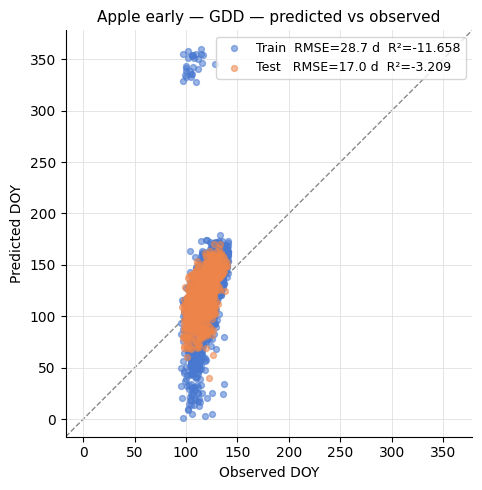

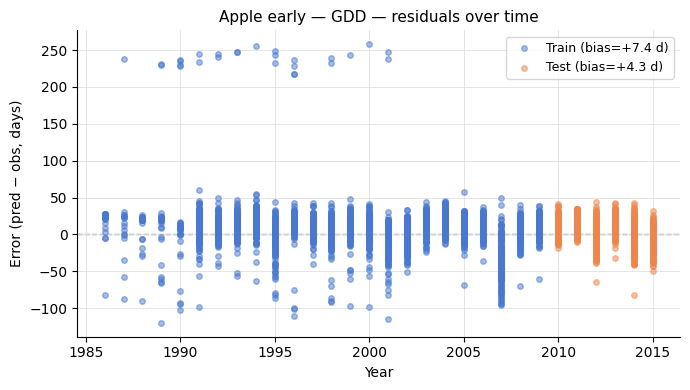

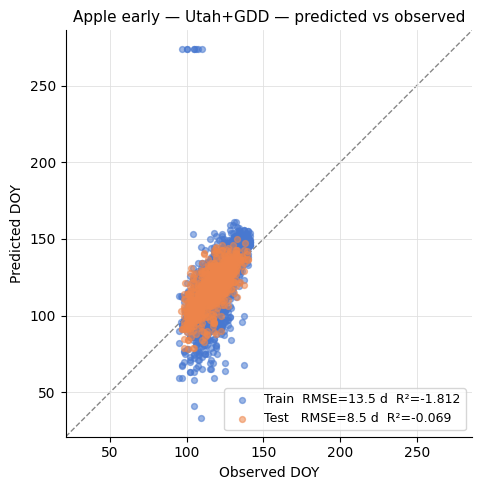

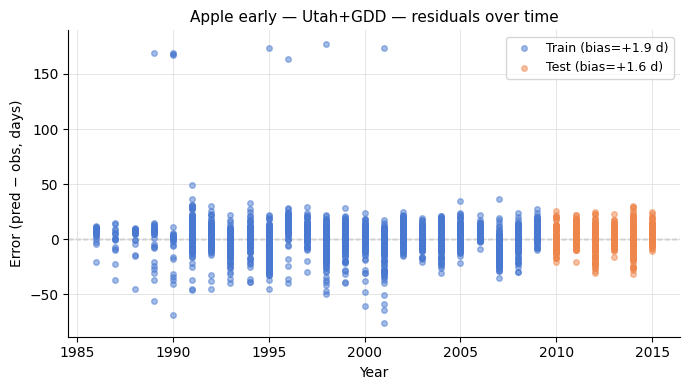

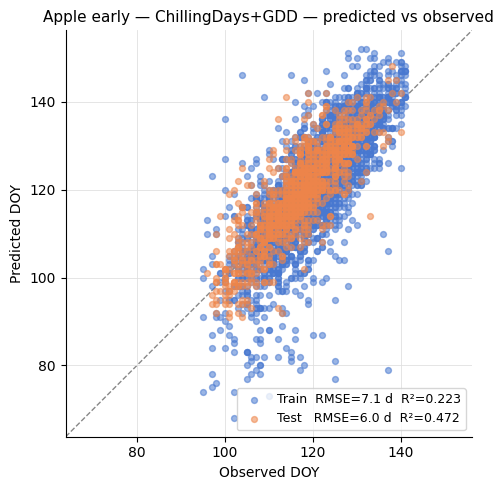

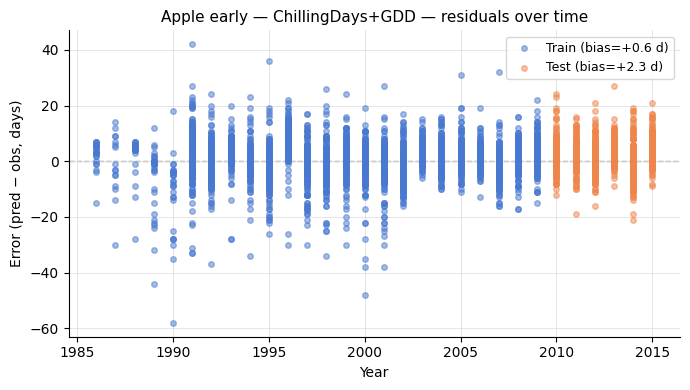

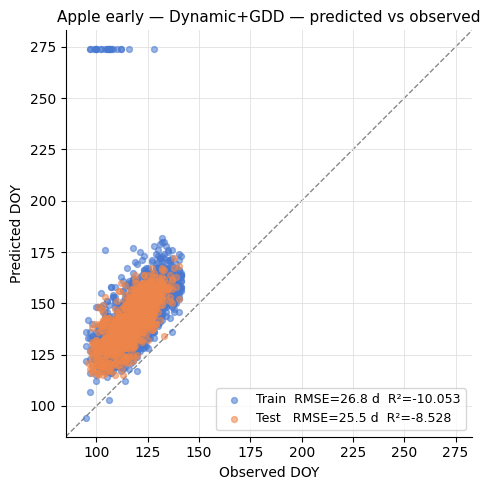

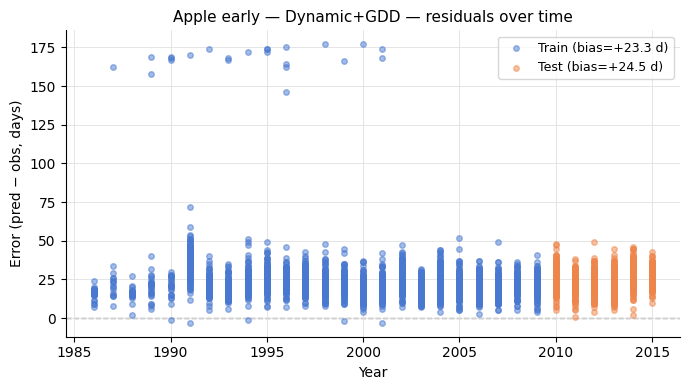

In [10]:
for name, result in results['early'].items():
    fig = result.plot_scatter(title=f'Apple early — {name} — predicted vs observed')
    plt.tight_layout()
    plt.show()

    fig = result.plot_residuals_over_time(title=f'Apple early — {name} — residuals over time')
    plt.tight_layout()
    plt.show()

### 5c. Evaluation plots — Late cultivar

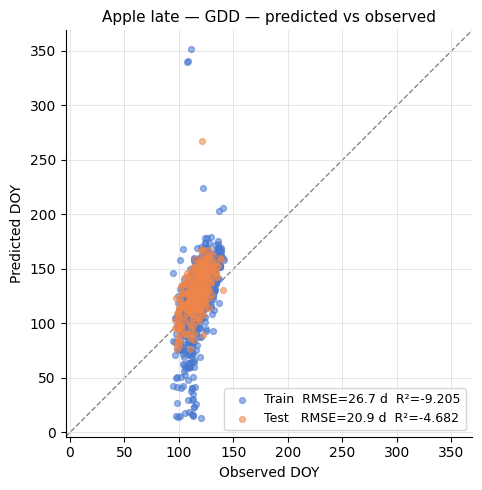

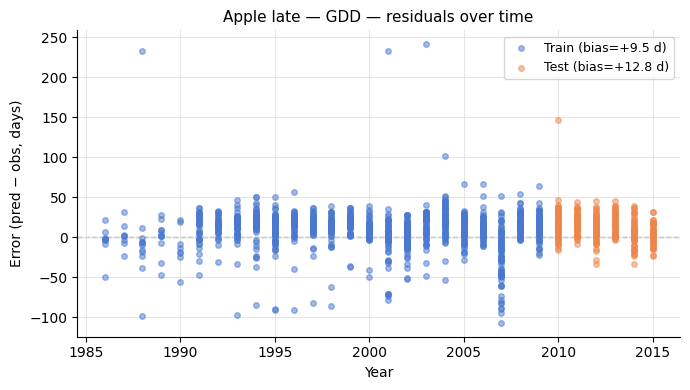

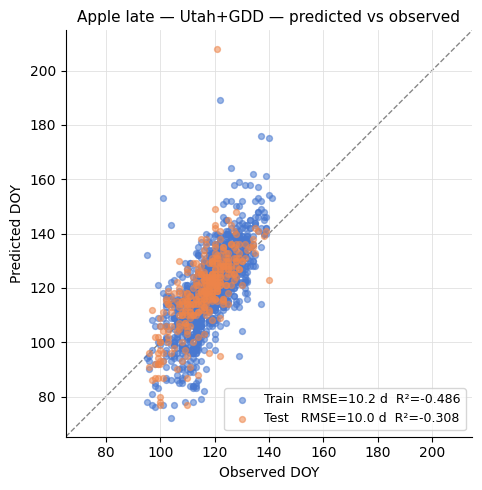

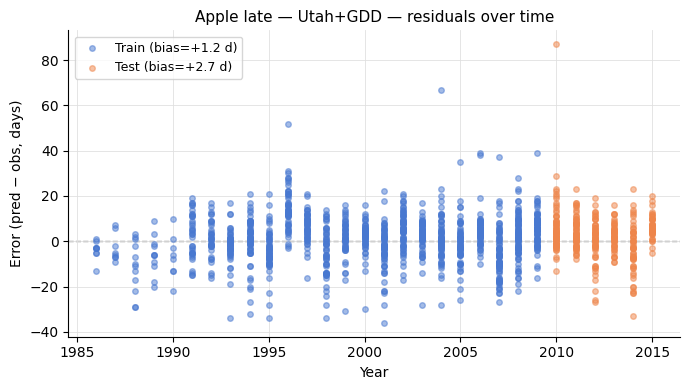

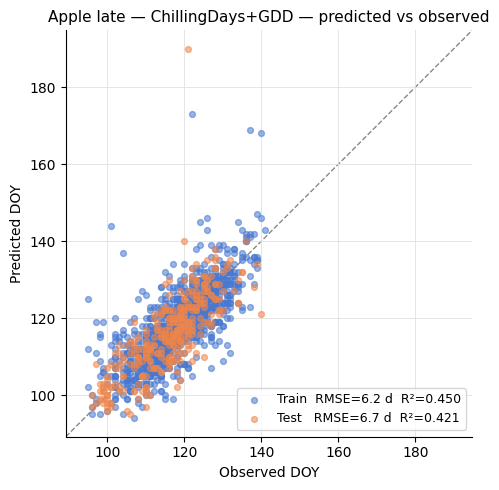

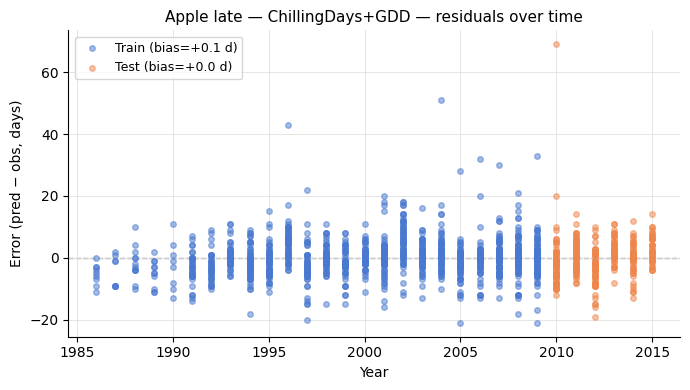

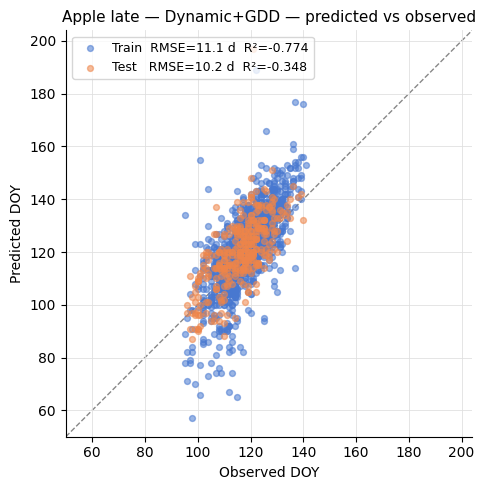

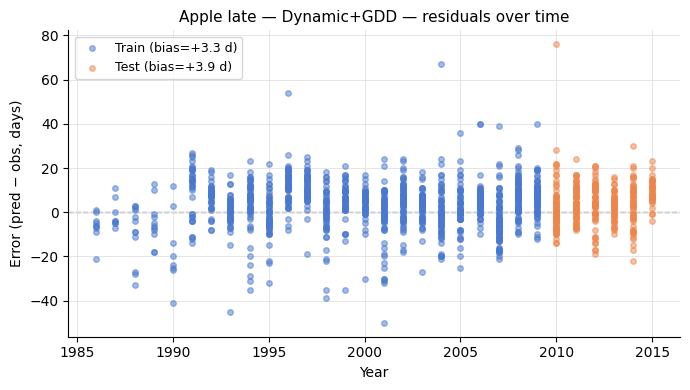

In [11]:
for name, result in results['late'].items():
    fig = result.plot_scatter(title=f'Apple late — {name} — predicted vs observed')
    plt.tight_layout()
    plt.show()

    fig = result.plot_residuals_over_time(title=f'Apple late — {name} — residuals over time')
    plt.tight_layout()
    plt.show()

## 6. Model response comparison on a single sample

We pick a representative sample from each cultivar group and visualise:

- **Top**: daily mean temperature over the season
- **Middle**: cumulative chill units per model (CF models only), with the fitted chilling threshold
- **Bottom**: cumulative forcing (GDU) per model — gated by chilling for CF models,
  ungated from season start for `GDDModel` — with the fitted forcing threshold and
  a vertical marker at the predicted bloom day

In [12]:
def pick_sample(ds, year=None):
    """Return the first sample for *year* (or the earliest available year)."""
    if year is None:
        year = min(ds.years)
    for item in ds.iter_items():
        if item['year'] == year:
            return item
    raise ValueError(f"No sample found for year {year}")


def compute_model_response(model, sample):
    """Return arrays needed for the response plot."""
    ts = sample[KEY_FEATURES]['temperature_2m_mean']

    if isinstance(model, (UtahGDDModel, ChillingDaysGDDModel, DynamicGDDModel)):
        cs, fs = model.get_cf_features(sample)
        chill_cs = np.cumsum(cs)
        chill_gate = (chill_cs >= model.threshold_c).astype(float)
        force_cs = np.cumsum(fs * chill_gate)
        th_c = model.threshold_c
        th_f = model.threshold_f
    elif isinstance(model, GDDModel):
        chill_cs = None
        th_c = None
        t_upper = model.t_upper
        ts_clipped = np.clip(ts, a_min=None, a_max=t_upper) if t_upper else ts
        force_cs = np.clip(ts_clipped - model.t_base, 0, None).cumsum()
        th_f = model.threshold
    else:
        raise TypeError(f"Unknown model type: {type(model)}")

    _, info = model.predict(sample)
    return dict(ts=ts, chill_cs=chill_cs, force_cs=force_cs,
                th_c=th_c, th_f=th_f, ix=info['ix'])


def plot_model_responses(sample, models_dict, group_label):
    """3-row figure: temperature / cumulative chill / cumulative forcing."""
    ts   = sample[KEY_FEATURES]['temperature_2m_mean']
    days = np.arange(len(ts))

    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D') -
                    np.datetime64(sample['season_start'], 'D')) /
                   np.timedelta64(1, 'D'))

    cf_names  = [n for n in models_dict if n != 'GDD']
    all_names = list(models_dict.keys())
    resp      = {n: compute_model_response(m, sample) for n, m in models_dict.items()}

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cmap   = {n: colors[i % len(colors)] for i, n in enumerate(all_names)}

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f'{group_label}  —  season {sample["year"]}', fontsize=13)

    ax = axes[0]
    ax.plot(days, ts, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.axvline(obs_ix, color='black', linewidth=1.0, linestyle=':', label=f'Observed (day {obs_ix})')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title('Daily mean temperature')

    ax = axes[1]
    for name in cf_names:
        r = resp[name]
        ax.plot(days, r['chill_cs'], label=name, color=cmap[name], linewidth=1.4)
        ax.axhline(r['th_c'], color=cmap[name], linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_ylabel('Cumulative chill units')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title('Chilling phase (CF models)')

    ax = axes[2]
    for name in all_names:
        r = resp[name]
        ax.plot(days, r['force_cs'], label=name, color=cmap[name], linewidth=1.4)
        ax.axhline(r['th_f'], color=cmap[name], linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axvline(r['ix'], color=cmap[name], linewidth=1.0, linestyle=':', alpha=0.8)
    ax.axvline(obs_ix, color='black', linewidth=1.2, linestyle='-',
               label=f'Observed (day {obs_ix})', zorder=5)
    ax.set_ylabel('Cumulative forcing (GDU)')
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title('Forcing phase (dashed = threshold, dotted = predicted day)')

    plt.tight_layout()
    return fig

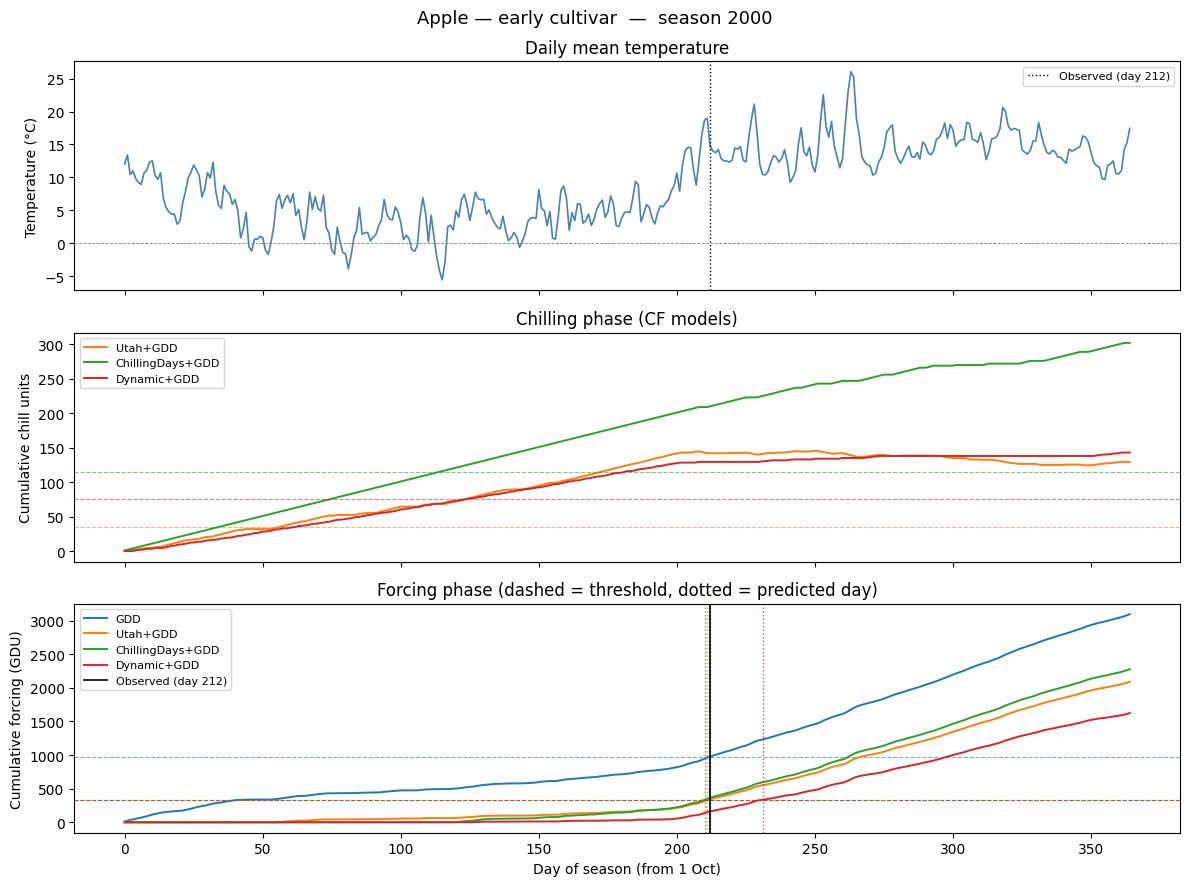

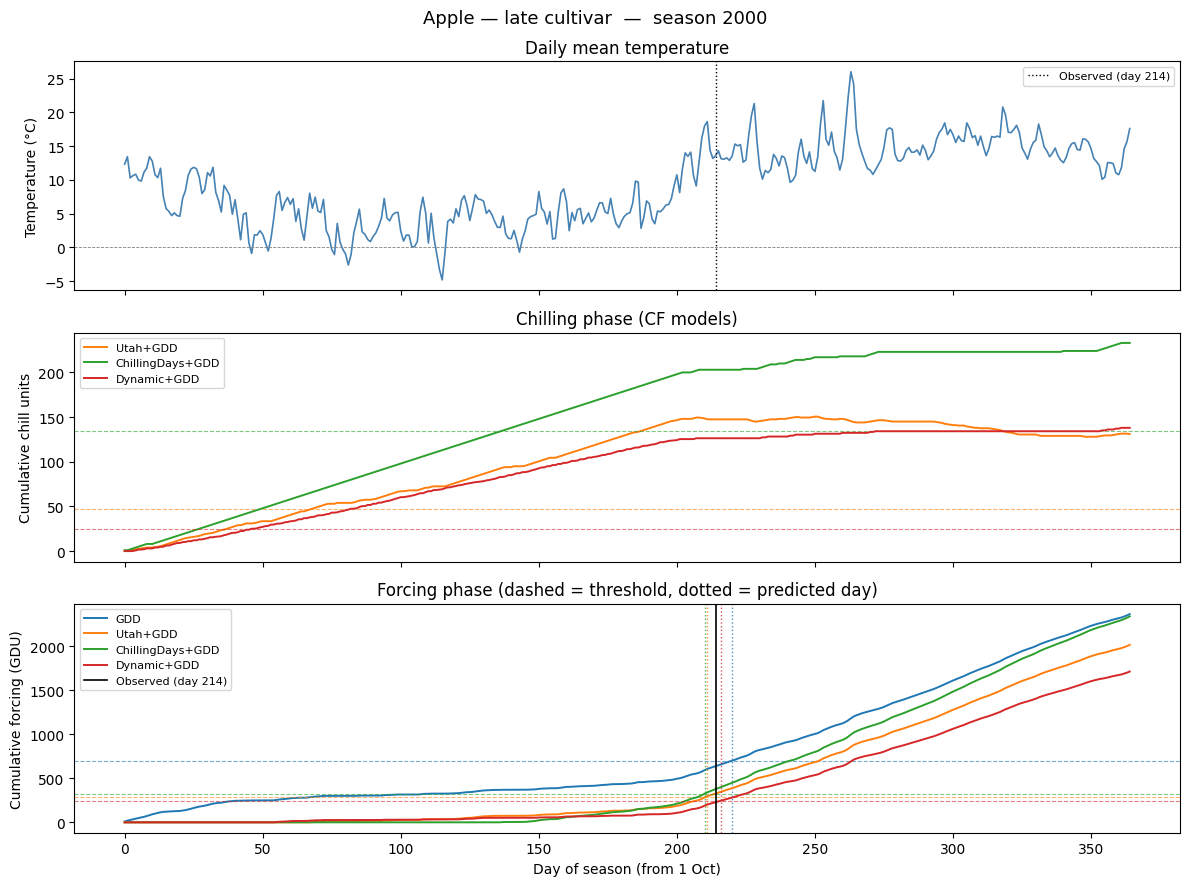

In [13]:
sample_early = pick_sample(ds_early, year=2000)
sample_late  = pick_sample(ds_late,  year=2000)

fig = plot_model_responses(sample_early, fitted['early'], 'Apple — early cultivar')
plt.show()

fig = plot_model_responses(sample_late, fitted['late'], 'Apple — late cultivar')
plt.show()

### 6a. Chilling model comparison on the same temperature input

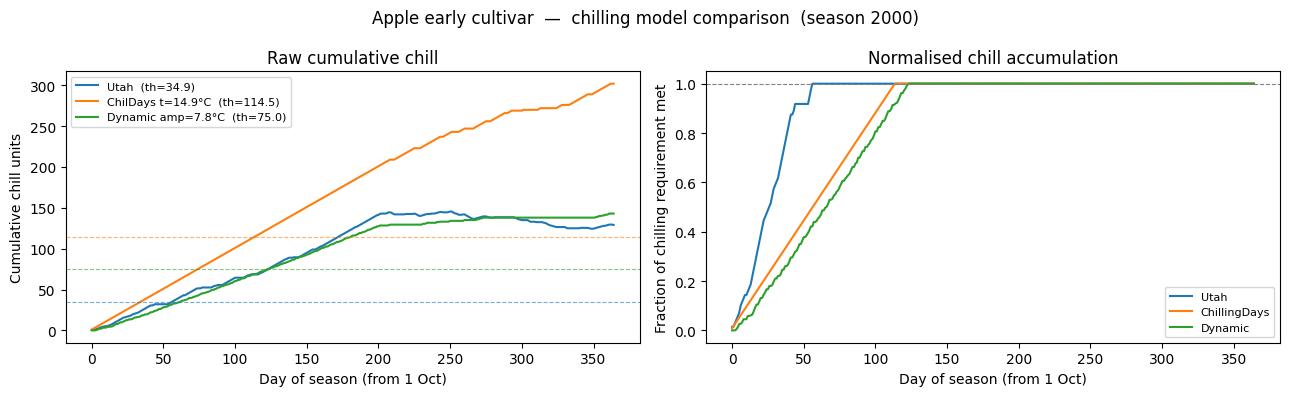

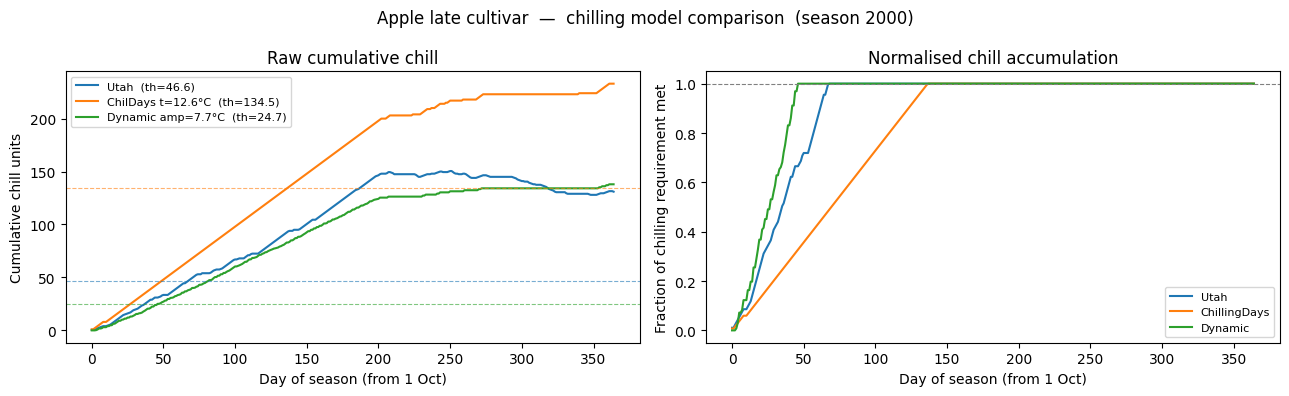

In [14]:
def plot_chill_comparison(sample, fitted_models, group_label):
    """Overlay the three chill-unit accumulation curves (raw and normalised)."""
    ts   = sample[KEY_FEATURES]['temperature_2m_mean']
    days = np.arange(len(ts))

    m_utah = fitted_models['Utah+GDD']
    m_cd   = fitted_models['ChillingDays+GDD']
    m_dyn  = fitted_models['Dynamic+GDD']

    utah_cs = np.cumsum(func_utah_chill(ts))
    cd_cs   = np.cumsum(func_chilling_days(ts, t_threshold=m_cd.t_chill))
    dyn_cs  = np.cumsum(func_dynamic_chill_daily(ts, amplitude=m_dyn.amplitude))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        f'{group_label}  —  chilling model comparison  (season {sample["year"]})',
        fontsize=12,
    )

    ax = axes[0]
    ax.plot(days, utah_cs, label=f'Utah  (th={m_utah.threshold_c:.1f})')
    ax.plot(days, cd_cs,   label=f'ChilDays t={m_cd.t_chill:.1f}°C  (th={m_cd.threshold_c:.1f})')
    ax.plot(days, dyn_cs,  label=f'Dynamic amp={m_dyn.amplitude:.1f}°C  (th={m_dyn.threshold_c:.1f})')
    ax.axhline(m_utah.threshold_c, color='C0', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(m_cd.threshold_c,   color='C1', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(m_dyn.threshold_c,  color='C2', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.set_ylabel('Cumulative chill units')
    ax.set_title('Raw cumulative chill')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(days, np.clip(utah_cs / m_utah.threshold_c, 0, 1), label='Utah')
    ax.plot(days, np.clip(cd_cs   / m_cd.threshold_c,   0, 1), label='ChillingDays')
    ax.plot(days, np.clip(dyn_cs  / m_dyn.threshold_c,  0, 1), label='Dynamic')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Day of season (from 1 Oct)')
    ax.set_ylabel('Fraction of chilling requirement met')
    ax.set_title('Normalised chill accumulation')
    ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


fig = plot_chill_comparison(sample_early, fitted['early'], 'Apple early cultivar')
plt.show()

fig = plot_chill_comparison(sample_late, fitted['late'], 'Apple late cultivar')
plt.show()

## 7. Save results

In [15]:
# for group in ('early', 'late'):
#     for name, result in results[group].items():
#         result.save()
#     for name, model in fitted[group].items():
#         model.save(f'{name.lower().replace("+", "_")}_apple_{group}')

# print('Saved.')